**makemore: becoming a backprop ninja**

完全使用之前 `4_MLP2_makemore.ipynb` 中的单个隐藏层的多层感知机（关于为什么是"单层", 详见： `4_MLP2_makemore.ipynb`中的 **✅总结** 部分 ）

# 基本代码

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [13]:
# 功能函数 用来比较梯度
# 主要是比较自己手动实现的和pytorch接口的梯度结果是否相同

def cmp(s,dt,t):
    """
    s: 要比较的梯度对象的名称 字符串
    dt: 自己算的dloss/dt的梯度结果
    t: torch张量对象，保存了梯度信息
    """
    ex = torch.all(dt == t.grad).item()  # exact 精确比较
    app = torch.allclose(dt,t.grad)   # approximate 近似比较   函数功能类似于 https://numpy.org/doc/stable/reference/generated/numpy.allclose.html
    maxdiff = (dt - t.grad).abs().max().item()   # 张量中最大梯度值差异
    print(f"{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {str(maxdiff):5s}")

In [3]:
# 初始化
n_embd = 10
n_hidden = 64 

g = torch.Generator().manual_seed(2147483647) 
# 输入层
C  = torch.randn((vocab_size, n_embd), generator=g)

# Layer1 隐藏层
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)*(5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g)*0.1

# Layer2 输出层
W2 = torch.randn((n_hidden, vocab_size), generator=g)*0.1
b2 = torch.randn(vocab_size,  generator=g)*0.1

# BN层
bngain = torch.randn(n_hidden)*0.1 + 1.0
bnbias = torch.randn(n_hidden)*0.1

# 注意，通常会将bias都初始化为0，但这里都初始化为比较小的数字，而不是精确的0
# 这是因为如果初始化为0，可能会掩盖梯度计算实现过程中的错误，所以这里改成比较小的小数，方便纠错自查
# 另外这里加了BN但是还在线性层用了bias，是因为只是想检查梯度的计算结果，并不是和网络训练相关

parameters = [C, W1,b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

4137


In [4]:
batch_size = 32
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

$$ Z = \frac{X - \mu}{\sigma} = \frac{X - \frac{1}{n} \sum_{i=1}^{n} x_i}{\sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}} = \frac{X - \bar{x}}{\sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}}$$


BN论文里的公式：   <https://arxiv.org/pdf/1502.03167>

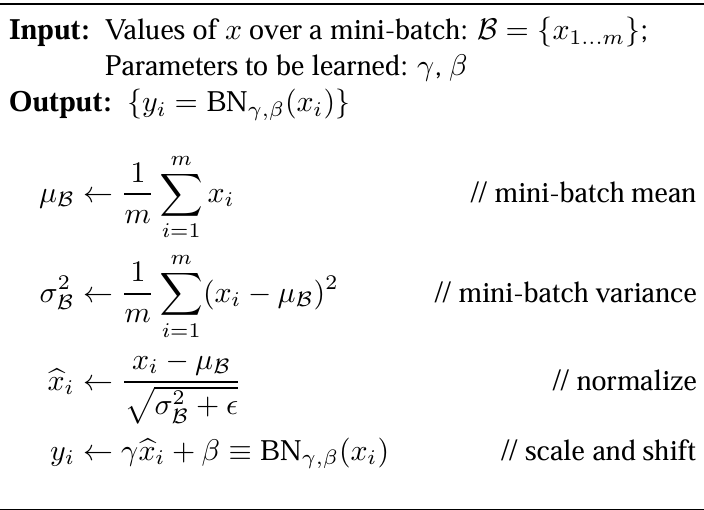

In [5]:
# forward pass
# 这里前向过程拆解的很细(单个op级别)，就是为了后续手动实现反向的时候，好实现
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1) 
# Linear Layer
hprebn = torch.tanh(embcat @ W1 + b1)    # hidden layer pre-activation
# BatchNorm Layer
bnmeani = (1/batch_size)*hprebn.sum(dim = 0, keepdim=True) # bessel correction 贝塞尔纠正 (1/(n-1))
bndiff = hprebn - bnmeani

bndiff2 = bndiff**2
bnvar = (1/batch_size)*bndiff2.sum(dim =0, keepdim = True) # 这里关于均值和方差的计算公式 详见: 4_MLP2_makemore.ipynb 中的  对正态分布进行标准化的公式
bnvar_inv = (bnvar + 1e-5)**(-0.5)  # inverse 上面公式里的分母

bnraw = bndiff*bnvar_inv

hpreact = bngain*bnraw + bnbias

h = torch.tanh(hpreact)  # non-linearity

# Linear Layer 2
logits = h @ W2 + b2 

# cross-entropy loss function(same as F.cross_entropy(logits, Yb))
# loss = F.cross_entropy(logits, Yb)
# 详见： 3_MLP_makemore.ipynb 中的 交叉熵损失函数
logit_maxes = logits.max(dim = 1, keepdim = True).values 
# 这里logits的shape应该是(batch_size,vocab_size), 所以在计算损失的时候，应该是一整行(一个样本的所有27中输出可能值)来处理的，所以要找每行的最大值，也就是在列上进行比较
norm_logits = logits - logit_maxes   # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(dim = 1, keepdim = True)
counts_sum_inv = counts_sum**(-1)  # 倒数, 从除法(除以counts_sum)变成乘法(乘以1/counts_sum)
# if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# 这里如果直接用除法，那么反向的时候会不精确 老师自己实验下来，发现pytorch的除法运算的反向传播实现数组有点奇怪，但是用乘法和负1次幂就没有这个问题
probs = counts*counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(batch_size), Yb].mean()

# 反向传播的时候，会对上面正向传播的变量，比如： logprobs，每个变量前面加个d，dlogprobs, 表示loss对logprobs的梯度值
# backward pass
for p in parameters:
    p.grad = None
# 因为后续要验证自己写的反向过程计算结果和pytorch的是否一样，因此，这里需要保留这些中间计算过程的梯度
# afaik  as far as I know 这里没有更简洁的写法了
for t in [logprobs, probs, counts_sum_inv, counts_sum, counts, norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, bnmeani, hprebn, embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.4018, grad_fn=<NegBackward0>)

# 练习

## 练习1-反向传播梯度计算和验证

In [10]:
# dlogprobs计算
# loss = -logprobs[range(batch_size), Yb].mean()
print(logprobs.shape, logprobs[range(batch_size), Yb].shape)
print(logprobs[range(batch_size), Yb])
# 因此，这里 loss的计算本质上等同于:
# loss = -(a + b + c)/3   
# dloss/da = -1/3
# 这里处理的不是3个数，而是32个数了，所以 dlogprobs/dloss = -1/32
# 那么对于[32,27]这个32行，每行27列的矩阵，每行里除了被Yb选中的那个参数梯度是 -1/32， 其余没被选中的梯度应该都是0(梯度为0表示没有影响，为1表示增大~)

torch.Size([32, 27]) torch.Size([32])
tensor([-3.9750, -3.0154, -3.5329, -3.3385, -4.1429, -3.3999, -3.4512, -4.3373,
        -3.2185, -4.3321, -3.0833, -1.4237, -2.8537, -2.7376, -2.8165, -3.4141,
        -3.7310, -3.1849, -3.5870, -3.5856, -2.7946, -2.8586, -4.3674, -4.0760,
        -3.6629, -2.9714, -3.2142, -4.2567, -2.8901, -3.9511, -3.4736, -3.1811],
       grad_fn=<IndexBackward0>)


In [15]:
# dprobs计算
# logprobs = probs.log()
# y = logx  dy/dx = 1/x  dloss/dprobs = dlogprobs * 1/probs
probs.shape

torch.Size([32, 27])

In [17]:
# dcounts 和 dcounts_sum_inv计算
# probs = counts*counts_sum_inv    # 这个操作本质上有两步，1. replication counts_sum_inv复制成27列 2.对应位置相乘
# dloss/dcounts = dprobs * counts_sum_inv
# dloss/dcounts_sum_inv = dprobs * counts
counts.shape, counts_sum_inv.shape, probs.shape
# 由于执行了广播的原因， 
# 本质上， 32行27列，乘以 32行1列
# 这里 counts的导数其实就是 counts_sum_inv的一列复制成27列即可
# 但是 counts_sum_inv的导数？？？

(torch.Size([32, 27]), torch.Size([32, 1]), torch.Size([32, 27]))

```bash
a b c      x1 o o    * * *
x x x   *  x2 o o  = * * *
x x x      x3 o o    * * *

                                 a11*b1 a12*b2 a13*b3
c = a * b = a[3, 3] * b[3,1] →   a21*b1 a22*b2 a23*b3   = c[3,3]
                                 a31*b1 a32*b2 a33*b3


```
dc/db1?  这里 b1与a11, a12, a13进行了乘法，这个就可以理解为是三个分支

在 `micrograd` 中，如果**在反向传播中，一个节点被多次使用，那么可以认为这个节点的梯度就是多个分支的梯度的和**。 详见： `1_micrograd_from_scratch.ipynb`中`## u9-梯度从赋值变成累加`里的内容

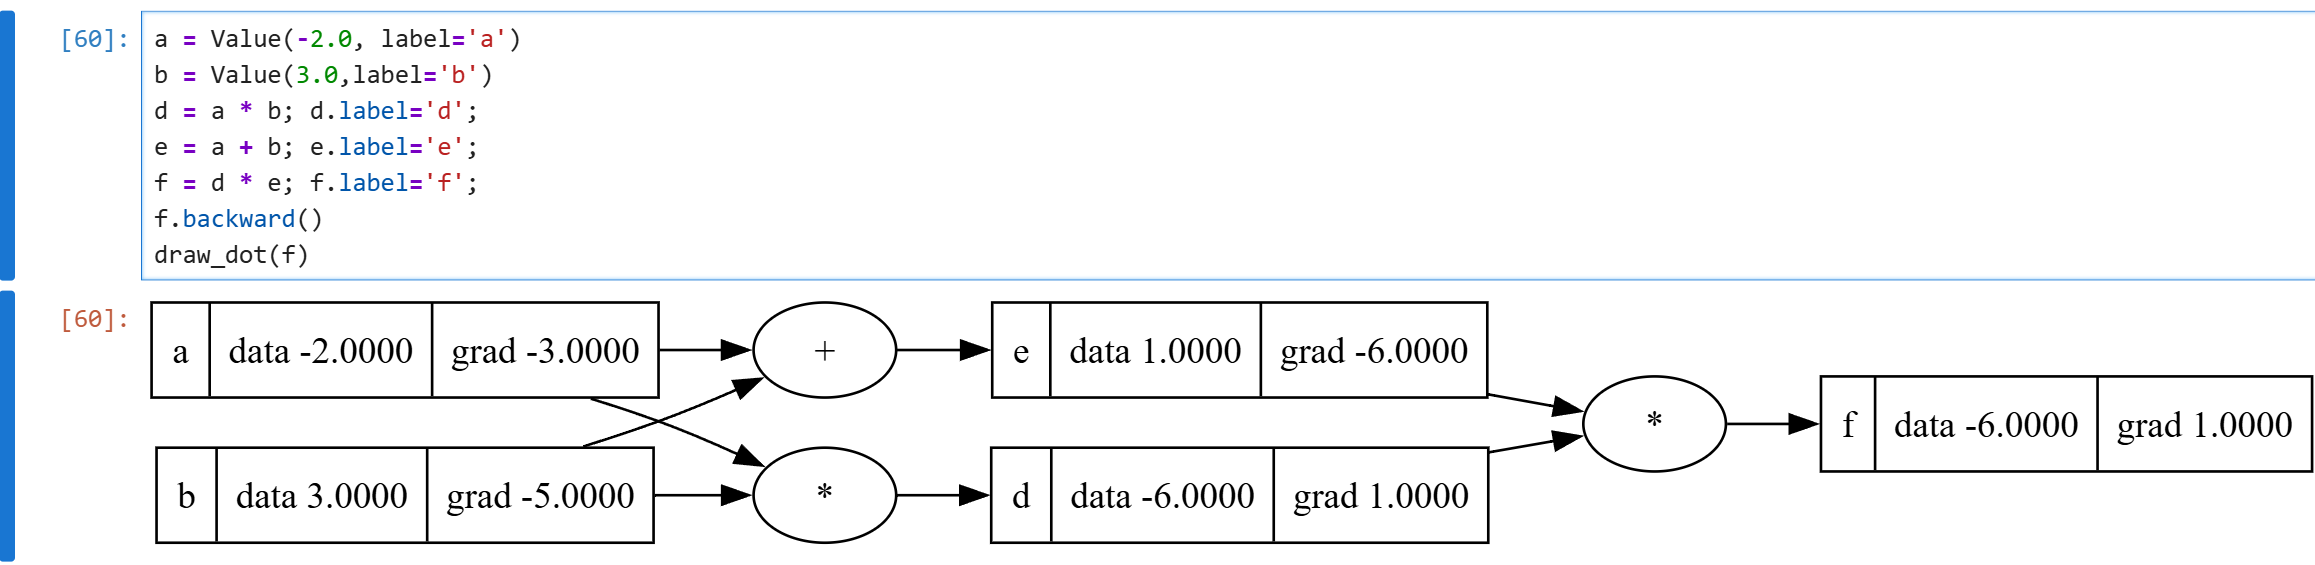

因此，对于b1,其梯度也是同行的a11,a12,a13的和

In [14]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one
# 练习1，手动反向传播所有变量，就像上面的正向传递中定义的那样，一个接一个地反向传播

# dlogprobs = torch.zeros((batch_size,vocab_size))
dlogprobs= torch.zeros_like(logprobs)
dlogprobs[range(batch_size), Yb] = -1.0/batch_size

dprobs = dlogprobs*(1.0/probs)   
# 如果预测正确，那么probs里对应元素的值就会接近1，1.0/probs≈1， 则最后求得的梯度肯定是<=dlogprobs的
# 如果预测不正确，那么probs里对应元素的值就会小于1，1.0/probs>1，则最后求得的梯度肯定是>dlogprobs的, 即大于正确结果的梯度，这样更新就会比较快

dcounts_sum_inv = 

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
# cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
# cmp('counts_sum', dcounts_sum, counts_sum)
# cmp('counts', dcounts, counts)
# cmp('norm_logits', dnorm_logits, norm_logits)
# cmp('logit_maxes', dlogit_maxes, logit_maxes)
# cmp('logits', dlogits, logits)
# cmp('h', dh, h)
# cmp('W2', dW2, W2)
# cmp('b2', db2, b2)
# cmp('hpreact', dhpreact, hpreact)
# cmp('bngain', dbngain, bngain)
# cmp('bnbias', dbnbias, bnbias)
# cmp('bnraw', dbnraw, bnraw)
# cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
# cmp('bnvar', dbnvar, bnvar)
# cmp('bndiff2', dbndiff2, bndiff2)
# cmp('bndiff', dbndiff, bndiff)
# cmp('bnmeani', dbnmeani, bnmeani)
# cmp('hprebn', dhprebn, hprebn)
# cmp('embcat', dembcat, embcat)
# cmp('W1', dW1, W1)
# cmp('b1', db1, b1)
# cmp('emb', demb, emb)
# cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0  
probs           | exact: True  | approximate: True  | maxdiff: 0.0  


## 练习2-求出交叉熵的解析解直接反向传播(不再逐操作传播)

In [ ]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out
# 反向传播cross_entropy交叉熵的导数,简化公式

# forward pass
# before
# logit_maxes = logits.max(dim = 1, keepdim = True).values 
# norm_logits = logits - logit_maxes
# counts = norm_logits.exp()
# counts_sum = counts.sum(dim = 1, keepdim = True)
# counts_sum_inv = counts_sum**(-1)  
# probs = counts*counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(batch_size), Yb].mean()



## 练习3-求出BN的解析解直接反向传播(不再逐操作传播)

In [ ]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# 求出BN的解析解,直接简化表达式

# forward pass
# before
# bnmeani = (1/n)*hprebn.sum(dim = 0, keepdim=True) 
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = (1/n)*bndiff2.sum(dim =0, keepdim = True) 
# bnvar_inv = (bnvar + 1e-5)**(-0.5)  
# bnraw = bndiff*bnvar_inv
# hpreact = bngain*bnraw + bnbias


## 练习4-综合上面简化后的结果完成整个训练过程

In [ ]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass